In [19]:
import pyzx as zx
import random
import matplotlib.pyplot as plt
from fractions import Fraction


def chsh_game(strategy):
    # Definimos el juego CHSH. La función strategy es la estrategia de Alice y Bob, que toma como entrada sus bits x e y, y devuelve sus respuestas a y b respectivamente.
    x, y = random.randint(0, 1), random.randint(0, 1)
    a, b = strategy(x, y)
    
    if (a != b) == (x & y):
        return 1
    return 0


# -Ahora construimos el circuito para la estrategia cuántica óptima. Alice y Bob comparten un e-bit, y luego aplican rotaciones Ry dependiendo de sus bits de entrada x e y. Finalmente, miden sus qubits para obtener sus respuestas a y b.
def chsh_circuit(x, y):
    c = zx.Circuit(2)
    
    c.add_gate("H", 0)
    c.add_gate("CNOT", 0, 1)
    

    def add_ry(circ, qubit, phase_fraction):
        # 1/2 en lugar de 0.5
        circ.add_gate("XPhase", qubit, phase=Fraction(1, 2))
        circ.add_gate("ZPhase", qubit, phase=phase_fraction)
        # -1/2 en lugar de -0.5
        circ.add_gate("XPhase", qubit, phase=Fraction(-1, 2))

    # Acciones de Alice
    if x == 1:
 
        add_ry(c, 0, Fraction(-1, 2))
        
    # Acciones de Bob
    if y == 0:
        add_ry(c, 1, Fraction(-1, 4))
    else:
        add_ry(c, 1, Fraction(1, 4))
        
    return c

(x,y) = (0,0)


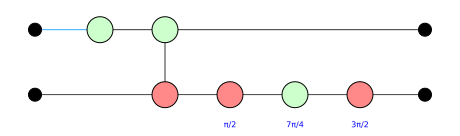

(x,y) = (0,1)


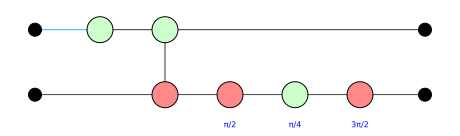

(x,y) = (1,0)


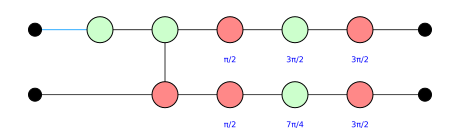

(x,y) = (1,1)


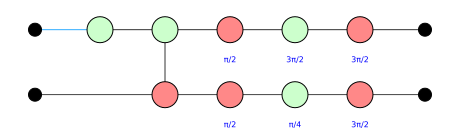

In [20]:
# Dibujar los cuatro circuitos posibles

print("(x,y) = (0,0)")
fig = zx.draw_matplotlib(chsh_circuit(0, 0))
display(fig)
plt.close(fig)

print("(x,y) = (0,1)")
fig = zx.draw_matplotlib(chsh_circuit(0, 1))
display(fig)
plt.close(fig)

print("(x,y) = (1,0)")
fig = zx.draw_matplotlib(chsh_circuit(1, 0))
display(fig)
plt.close(fig)

print("(x,y) = (1,1)")
fig = zx.draw_matplotlib(chsh_circuit(1, 1))
display(fig)
plt.close(fig)

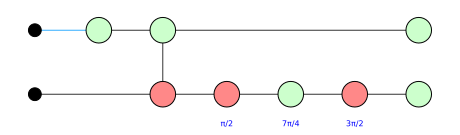

In [21]:
chsh00 = chsh_circuit(0, 0).to_graph()
chsh01 = chsh_circuit(0, 1).to_graph()  
chsh10 = chsh_circuit(1, 0).to_graph()
chsh11 = chsh_circuit(1, 1).to_graph()

salida_0 = chsh00.outputs()[0]
salida_1 = chsh00.outputs()[1]


chsh00.set_type(salida_0, zx.VertexType.Z)
chsh00.set_type(salida_1, zx.VertexType.Z)

zx.draw_matplotlib(chsh00)

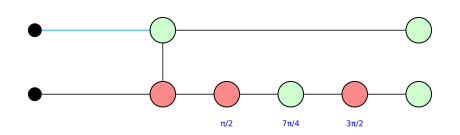

In [22]:
from pyzx.simplify import *

while True:
    while True:
        i1 = id_simp(chsh00)
        i2 = pivot_simp(chsh00)
        if i1 or i2: 
            fig = zx.draw_matplotlib(chsh00)
            display(fig)
            plt.close(fig)

        i4 = lcomp_simp(chsh00)
        if i4: 
            fig = zx.draw_matplotlib(chsh00)
            display(fig)
            plt.close(fig)

        if not (i1 or i2 or i4): break

    i2 = pivot_boundary_simp(chsh00)
    if i2: 
        fig = zx.draw_matplotlib(chsh00)
        display(fig)
        plt.close(fig)
    if not i2: break



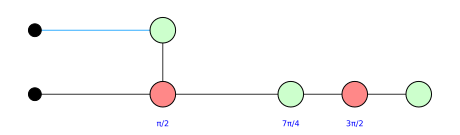

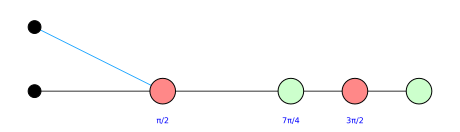

In [24]:
while True:
    while True:
        i1 = id_simp(chsh00)
        i2 = spider_simp(chsh00)
        i3 = pivot_simp(chsh00)
        if i1 or i2 or i3: 
            fig = zx.draw_matplotlib(chsh00)
            display(fig)
            plt.close(fig)
        i4 = lcomp_simp(chsh00)
        if i4: 
            fig = zx.draw_matplotlib(chsh00)
            display(fig)
            plt.close(fig)
        if not (i1 or i2 or i3 or i4): break

    i2 = pivot_boundary_simp(chsh00)
    if i2: 
        fig = zx.draw_matplotlib(chsh00)
        display(fig)
        plt.close(fig)
    if not i2: break

Definimos la estrategia cuántica. Como PyZX no tiene simulador probabilístico, extraemos el vector de estado del circuito y calculamos las probabilidades de cada estado

In [29]:
import numpy as np

def quantum_strategy(x, y):
    # 1. Generamos el circuito para las entradas x, y
    circ = chsh_circuit(x, y)
    
    matriz = circ.to_matrix()
    
    # Extraemos la primera columna (el estado asumiendo que empezamos en |00>)
    statevector = matriz[:, 0]
    
    # 3. Calculamos las probabilidades
    probabilidades = np.abs(statevector)**2
    
    # Aplanamos el array a una lista normal de Python por pura seguridad
    probabilidades = probabilidades.flatten().tolist()
    
    # 4. Simulamos un solo disparo (shots=1) basado en las probabilidades
    estados_posibles = ['00', '01', '10', '11']
    resultado_simulado = random.choices(estados_posibles, weights=probabilidades, k=1)[0]
    
    # 5. Extraemos los bits individuales para Alice (a) y Bob (b)
    a, b = int(resultado_simulado[0]), int(resultado_simulado[1])
    
    return a, b

Ejecutamos un bucle del juego para ver las victorias de la estrategia cuántica

In [28]:
NUM_GAMES = 1000
victorias = 0

for _ in range(NUM_GAMES):
    victorias += chsh_game(quantum_strategy)

tasa_victoria = victorias / NUM_GAMES
print(f"Tasa de victoria cuántica: {tasa_victoria * 100}%")

Tasa de victoria cuántica: 86.1%
